# Part 1

In [1]:
from scipy.sparse.linalg import LinearOperator
from scipy.sparse import coo_matrix
from scipy.sparse import csr_matrix
from scipy.sparse import random
from scipy.sparse.linalg import gmres, cg
from scipy.sparse import diags
from scipy.sparse import bmat

import numpy as np
import timeit
import matplotlib.pyplot as plt

## 1.1
Make a copy of this code snippet and implement the methods __init__, __add__ and matvec. The method __init__ takes a COO matrix as input and will initialise the CSR matrix: it currently includes one line that will store the shape of the input matrix. You should add code here that extracts important data from a Scipy COO and computes and stores the appropriate data for a CSR matrix. You may use any functionality of Python and various libraries in your code, but you should not use a library’s implementation of a CSR matrix. The method __add__ will overload + , so you will be able to add two of your CSR matrices together. The __add__ method should avoid converting any matrices to dense matrices. You could implement this in one of two ways: you could convert both matrices to COO matrices, compute the sum, then pass this into CSRMatrix(); or you could compute the data, indices and indptr for the sum, and use these to create a SciPy CSR matrix. The method matvec will define a matrix-vector product: Scipy will use this when you tell it to use a sparse solver on your operator.

In [ ]:
# COO conversion
class CSRMatrix(LinearOperator):
    def __init__(self, coo_matrix):
        "Inputs a COO matrix and outputs CSR matrix pramaters"
        self.shape = coo_matrix.shape
        self.dtype = coo_matrix.dtype

        #Extract COO matrix data to be used to manually convert to CSR formatting.
        rows = coo_matrix.row
        cols = coo_matrix.col
        data = coo_matrix.data

        #Get CSR information
        sorted_indices = np.lexsort((cols, rows))
        rows = rows[sorted_indices]
        cols = cols[sorted_indices]
        data = data[sorted_indices]

        # Calculate CSR representation
        self.indptr = np.zeros(self.shape[0] + 1, dtype=np.int32)
        np.add.at(self.indptr, rows + 1, 1)
        self.indptr = np.cumsum(self.indptr)
        self.indices = cols
        self.data = data

        #Store as scipy csr matrix for conveniance
        self.scipy = csr_matrix((self.data, self.indices, self.indptr), shape=(self.shape[0],self.shape[1]))
        pass

    def __add__(self, other):
        """Add the CSR matrix other to this matrix."""
        if self.shape != other.shape:
            raise ValueError("Matrices must have the same shape")

        # get COO information
        self_row = np.repeat(np.arange(len(self.indptr) - 1), np.diff(self.indptr))
        self_col = self.indices
        self_data = self.data

        other_row = np.repeat(np.arange(len(other.indptr) - 1), np.diff(other.indptr))
        other_col = other.indices
        other_data = other.data

        # Convert to COO format and sum
        self_coo = coo_matrix((self_data, (self_row, self_col)), shape=self.shape)
        other_coo = coo_matrix((other_data, (other_row, other_col)), shape=other.shape)

        sum_coo = (self_coo + other_coo).tocoo()
        CSR = CSRMatrix(sum_coo)

        return CSR.scipy

    # Included CSR method after resolving code issue it now works as intended.
    def __sub__(self, other):
        """Add the CSR matrix other to this matrix."""
        if self.shape != other.shape:
            raise ValueError("Matrices must have the same shape")

        # Initialise arrays
        sum_indptr = [0]
        sum_indices = []
        sum_data = []

        for i in range(len(self.indptr) - 1):
            # Get start and end indices of each row
            start1, end1 = self.indptr[i], self.indptr[i + 1]
            start2, end2 = other.indptr[i], other.indptr[i + 1]

            # Get slices for each row
            indices1, data1 = self.indices[start1:end1], self.data[start1:end1]
            indices2, data2 = other.indices[start2:end2], other.data[start2:end2]

            # Combine indices and data
            indices = np.concatenate((indices1, indices2))
            data = np.concatenate((data1, data2))

            # Sum duplicates
            unique_indices, inverse = np.unique(indices, return_inverse=True)
            summed_data = np.zeros_like(unique_indices, dtype=data.dtype)
            np.add.at(summed_data, inverse, data)

            # Append results for the current row
            sum_indices.extend(unique_indices)
            sum_data.extend(summed_data)
            sum_indptr.append(len(sum_indices))

        # Create the resulting CSR matrix
        sum_csr = csr_matrix((sum_data, sum_indices, sum_indptr), shape=self.shape)
        return sum_csr

    def _matvec(self, vector):
        """
        Computes matrix product Ax = b
        where A is the CSR matrix and x and b are vectors.
        """
        if vector.shape != (self.shape[1],):
            raise ValueError("Vector must have shape ({},)".format(self.shape[1]))

        result = np.zeros(self.shape[0], dtype=self.dtype)

        for i in range(len(self.indptr) - 1):
            # Get start and end of the row
            row_start = self.indptr[i]
            row_end = self.indptr[i + 1]

            # Slice indices and data for the current row
            row_indices = self.indices[row_start:row_end]
            row_data = self.data[row_start:row_end]

            # Compute dot product for the row
            result[i] = np.dot(row_data, vector[row_indices])

        return result

In [ ]:
# Test class functions
#Set up test COO matrices
rows = 20
cols = 20
density = 0.3

coo1 = random(rows, cols, density, format='coo', data_rvs=np.random.rand)
coo2 = random(rows, cols, density, format='coo', data_rvs=np.random.rand)
vec1 = np.random.rand(rows)

CSR1 = CSRMatrix(coo1)
CSR2 = CSRMatrix(coo2)
add_test = CSR1 + CSR2 # Test overide addition (+)
add2_test = CSR1 - CSR2 # alternate addition method
matvec_test = CSR1 * vec1 # Test overide multiplication (* and @)

#Assert class calculations against CSR library
csr1 = csr_matrix(coo1)
csr2 = csr_matrix(coo2)
add_goal = csr_matrix(csr1 + csr2)
matvec_goal = csr_matrix(csr1@vec1)

# Check output matrices are equal
def assert_csr_matrices_equal(matrix1: csr_matrix, matrix2: csr_matrix):
    """
    Assert that two CSR matrices are equal.

    Parameters:
    - matrix1 (csr_matrix): The first CSR matrix.
    - matrix2 (csr_matrix): The second CSR matrix.
    """

    assert isinstance(matrix1, csr_matrix), "matrix1 is not a CSR matrix"
    assert isinstance(matrix2, csr_matrix), "matrix2 is not a CSR matrix"

    # Compare shapes
    assert matrix1.shape == matrix2.shape, f"Shapes are different: {matrix1.shape} != {matrix2.shape}"

    # Compare data arrays
    assert np.allclose(matrix1.data, matrix2.data), f"Data arrays are different: {matrix1.data} != {matrix2.data}"

    # Compare index arrays
    assert np.allclose(matrix1.indices, matrix2.indices), f"Indices arrays are different: {matrix1.indices} != {matrix2.indices}"

    # Compare index pointer arrays
    assert np.allclose(matrix1.indptr, matrix2.indptr), f"Index pointer arrays are different: {matrix1.indptr} != {matrix2.indptr}"

assert_csr_matrices_equal(add_test, add_goal)
assert_csr_matrices_equal(add2_test, add_goal)
assert (matvec_test == matvec_goal).all()

print('All tests passed :3')

All tests passed :3


## 1.2
For a collection of sparse matrices of your choice and a random vector, measure the time taken to perform a matvec product. Convert the same matrices to dense matrices and measure the time to compute a dense matrix-vector product using Numpy. Create a plot showing the times of matvec and Numpy for a range of matrix sizes and briefly (1-2 sentence) comment on what your plot shows.

In [ ]:
# Generate sparse matrices and vectors
N = np.linspace(100,4000,50).astype(int)
density = 0.3
loops = 10

coo_matrices = []
vectors = []
for i in N:
    rows = i
    cols = i
    coo_matrices.append(random(rows, cols, density, format='coo', data_rvs=np.random.rand))
    vectors.append(np.random.rand(cols))

# Time _matvec function
matvec_times = []
np_times = []
for i, coo_matrix in enumerate(coo_matrices):
    CSR = CSRMatrix(coo_matrix)
    vector = vectors[i]
    t_matvec = timeit.timeit(lambda: CSR @ vector, number=loops)
    t_np = timeit.timeit(lambda: coo_matrix.todense()@vector, number=loops)
    matvec_times.append(t_matvec/loops) #Divide by loops to get average runtime
    np_times.append(t_np/loops)
    print(f"\rProcessing: {i+1}/50", end="", flush=True)

Processing: 50/50

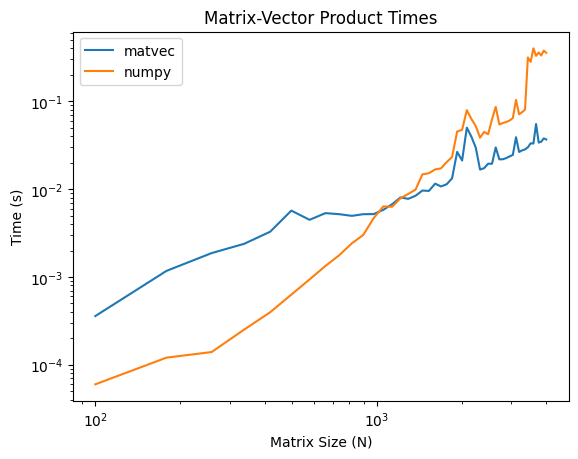

In [ ]:
# plot times
plt.plot(N, matvec_times, label='matvec')
plt.plot(N, np_times, label='numpy')
plt.xlabel('Matrix Size (N)')
plt.ylabel('Time (s)')
plt.xscale('log')
plt.yscale('log')
plt.title('Matrix-Vector Product Times')
plt.legend()

The plot shows that the average runtime for larger
N increases at a faster rate for the NumPy dense calculation compared to the CSRMatrix sparse implementation. This difference arises from the increasingly effective sparse formatting in CSRMatrix as N grows, allowing it to skip over a greater number of zero values optimising memory and computation. Overall, it can be concluded that NumPy method, due to its optimisations, is faster for smaller matrices but falls behind for larger N, where it has to process a significant amount of redundant data.

## 1.3
For a matrix of your choice and a random vector, use Scipy’s gmres and cg sparse solvers to solve a matrix problem using your CSR matrix. Check if the two solutions obtained are the same. Briefly comment (1-2 sentences) on why the solutions are or are not the same (or are nearly but not exactly the same).

In [ ]:
def create_spd_matrix(rows, density=0.3):
    """
    Create a symmetric positive definite sparse matrix.
    """
    np.random.seed(64)
    diagonal = np.random.uniform(1, 10, rows)
    sub_diagonal = np.random.uniform(0.1, 1, rows - 1)
    diagonals = [diagonal, sub_diagonal, sub_diagonal]
    A = diags(diagonals, [0, -1, 1], format="coo")
    return A

# Set parameters
rows = 20
cols = 20
density = 0.3

# Create a symmetric positive definite matrix
Matrix = create_spd_matrix(rows, density)
vector = np.random.rand(cols)
cg_product,_ = cg(Matrix, vector)
gmres_product,_ = gmres(Matrix, vector)

# Check overall symmetery for CG
is_symmetric = np.allclose(Matrix.todense(), Matrix.T.todense())
print(f'Matrix is symmetric: {is_symmetric}')
# Check positive eigenvalues
eigenvalues = np.linalg.eigvals(Matrix.todense())
is_positive_definite = np.all(eigenvalues > 0)
print(f'Matrix is positive definite: {is_positive_definite}')

print(f'CG product: \n{cg_product}')
print(f'GMRES product: \n{gmres_product}')
assert np.allclose(gmres_product, cg_product, atol=1e-6)
print('Calculated results are the same :3')
print('')

Matrix is symmetric: True
Matrix is positive definite: True
CG product: 
[ 0.07688435  0.08349502  0.0866462   0.11797647  0.03690331  0.031448
  0.00088537  0.25823079  0.13644032  0.13019809  0.09728143  0.00501876
  0.11381361  0.21279974 -0.14023069  0.28802904  0.38646783  0.07572155
  0.06807319  0.20345798]
GMRES product: 
[ 0.07688446  0.08349494  0.08664617  0.11797658  0.03690322  0.03144819
  0.00088539  0.25823068  0.13644025  0.13019823  0.09728142  0.00501872
  0.11381365  0.21279992 -0.14023061  0.28802901  0.38646784  0.07572154
  0.06807316  0.20345791]
Calculated results are the same :3



The results from CG and GMRES are the same because the matrix is symmetric and positive definite (SPD). CG works only on SPD matrices, and GMRES works on any matrix, but for SPD matrices, both methods solve the system in a way that minimises the error similarly, leading to a very similar result.








# Part 2

## 2.1
Let A
be a 2𝑛 by 2𝑛 matrix with the following structure:
The top left 𝑛 by 𝑛 block of A is a diagonal matrix
The top right 𝑛 by 𝑛 block of A is zero
The bottom left 𝑛 by 𝑛 block of A is zero
The bottom right 𝑛 by 𝑛 block of A is dense (but has a special structure defined below)

Let Ã be the bottom right  𝑛 by  𝑛 block of A. Suppose that Ã  is a matrix that can be written as

Ã =TW,

where T is a 𝑛 by 2 matrix (a tall matrix); and where W is a 2 by 𝑛 matrix (a wide matrix).

Implement a Scipy LinearOperator for matrices of this form. Your implementation must include a matrix-vector product (matvec) and the shape of the matrix (self.shape), but does not need to include an __add__ function. In your implementation of matvec, you should be careful to ensure that the product does not have more computational complexity then necessary.

In [ ]:
# Define Block Matrix class

class BLOCKmatrix(LinearOperator):
    def __init__(self, T_mat, W_mat, D_vec):
        self.n = T_mat.shape[0]
        self.shape = (2 * self.n, 2 * self.n)
        self.dtype = T.dtype

        self.D_vec = D_vec  # nx1
        self.T_mat = T_mat  # nx2
        self.W_mat = W_mat  # 2xn
        pass

    def _matvec(self, vector):
        """
        Computes matrix product Ax = b
        where A is the CSR matrix and x and b are vectors.
        """
        if vector.shape != (self.shape[1],):
            raise ValueError("Vector must have shape ({},)".format(self.shape[1]))

        # Resultant vector will have Top half Dx and bottom half TWx
        # We split x into two nx1 halves that act on respective matrix parts
        vec_t, vec_b = vector[:self.n], vector[self.n:]

        # Top half: Dx
        Dx = self.D_vec * vec_t

        # Bottom half: TWx
        TW = self.T_mat @ self.W_mat
        TWx = TW @ vec_b

        return np.concatenate([Dx, TWx])

## 2.2

For a range of values of n, create matrices where the entries on the diagonal of the top-left block and in the matrices T and W are random numbers. For each of these matrices, compute matrix-vector products using your implementation and measure the time taken to compute these. Create an alternative version of each matrix, stored using a Scipy or Numpy format of your choice, and measure the time taken to compute matrix-vector products using this format. Make a plot showing time taken against n. Comment (2-4 sentences) on what your plot shows, and why you think one of these methods is faster than the other (or why they take the same amount of time if this is the case).



In [ ]:
# Test function accuracy
n = 20
D = np.random.rand(n)
T = np.random.rand(n, 2)
W = np.random.rand(2, n)
vector = np.random.rand(2*n * 1)

# Create instances of BLOCKmatrix and Scipy Sparse representation
block_matrix = BLOCKmatrix(T, W, D)
sparse_matrix = bmat([[diags(D), None], [None, T @ W]], format="csr")

assert np.allclose(block_matrix @ vector, sparse_matrix @ vector)
print('Function works as intended :3')

Function works as intended :3


In [ ]:
N = np.linspace(100,4000,50).astype(int)
loops = 10

time_block = []
time_sparse = []

for i,n in enumerate(N):
    # Generate random matrices
    D = np.random.rand(n)
    T = np.random.rand(n, 2)
    W = np.random.rand(2, n)
    vector = np.random.rand(2*n * 1)

    # Create instances of BLOCKmatrix and Scipy Sparse representation
    block_matrix = BLOCKmatrix(T, W, D)
    sparse_matrix = bmat([[diags(D), None], [None, T @ W]], format="csr")

    # Measure time for BLOCKmatrix
    t = timeit.timeit(lambda: block_matrix @ vector, number=loops)
    time_block.append(t/loops)

    # Measure time for Sparse Matrix
    t = timeit.timeit(lambda: sparse_matrix @ vector, number=loops)
    time_sparse.append(t/loops)

    print(f"\rProcessing: {i+1}/50", end="", flush=True)

Processing: 50/50

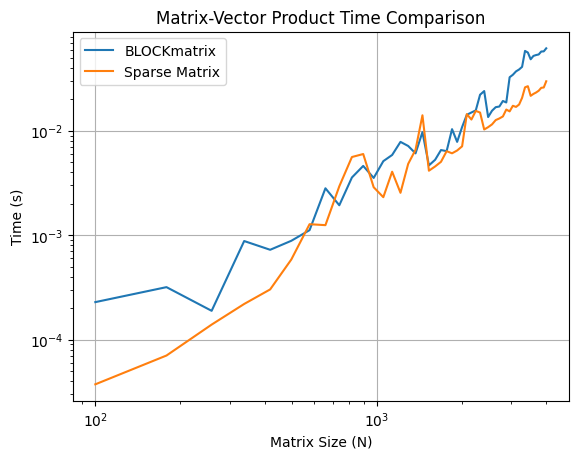

In [ ]:
# Plotting results
plt.plot(N, time_block, label='BLOCKmatrix')
plt.plot(N, time_sparse, label='Sparse Matrix')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix Size (N)')
plt.ylabel('Time (s)')
plt.title('Matrix-Vector Product Time Comparison')
plt.legend()
plt.grid(True)
plt.show()

From the plot, we observe that both the sparse and implemented BLOCK matrix methods yield similar results. For smaller
N, the BLOCK method is slower, primarily due to its initialisations. However, as N increases, the time lost becomes negligible, allowing it to keep pace with the sparse method overall. For larger
N, however, the sparse method is faster, leveraging its optimizations for large-scale data.